In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

ROOT      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(ROOT, 'data', 'processed')
OUTPUTS   = os.path.join(ROOT, 'outputs')

print("Imports OK ✓")
print("Root:", ROOT)

Imports OK ✓
Root: C:\Users\aniru\OneDrive\Desktop\Retail Seg


In [2]:
rfm_uci  = pd.read_parquet(os.path.join(PROCESSED, 'rfm_uci.parquet'))
rfm_hm   = pd.read_parquet(os.path.join(PROCESSED, 'rfm_hm.parquet'))
rfm_inst = pd.read_parquet(os.path.join(PROCESSED, 'rfm_inst.parquet'))

for name, df in [('UCI', rfm_uci), ('H&M', rfm_hm), ('Instacart', rfm_inst)]:
    print(f"{name:12} — {len(df):>10,} customers | columns: {df.columns.tolist()}")

UCI          —      5,878 customers | columns: ['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']
H&M          —  1,362,281 customers | columns: ['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']
Instacart    —    206,209 customers | columns: ['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']


In [15]:
def cap_outliers(rfm, cap_percentile=99):
    """
    Cap monetary and frequency at the given percentile.
    Preserves original values in separate columns for reference.
    """
    rfm = rfm.copy()

    mon_cap  = rfm['monetary'].quantile(cap_percentile / 100)
    freq_cap = rfm['frequency'].quantile(cap_percentile / 100)

    rfm['monetary_raw']   = rfm['monetary']
    rfm['frequency_raw']  = rfm['frequency']

    rfm['monetary']  = rfm['monetary'].clip(upper=mon_cap)
    rfm['frequency'] = rfm['frequency'].clip(upper=freq_cap)

    print(f"Monetary  cap @ {cap_percentile}th pct: £{mon_cap:,.2f}")
    print(f"Frequency cap @ {cap_percentile}th pct: {freq_cap:.0f} orders")
    print(f"Customers affected (monetary):  "
          f"{(rfm['monetary_raw'] > mon_cap).sum():,}")
    print(f"Customers affected (frequency): "
          f"{(rfm['frequency_raw'] > freq_cap).sum():,}")
    return rfm


print("=" * 40)
print("UCI — Capping outliers")
print("=" * 40)
rfm_uci_capped = cap_outliers(rfm_uci)

print("\n" + "=" * 40)
print("H&M — Capping outliers")
print("=" * 40)
rfm_hm_capped = cap_outliers(rfm_hm)

print("\n" + "=" * 40)
print("Instacart — Capping outliers")
print("=" * 40)
rfm_inst_capped = cap_outliers(rfm_inst)

UCI — Capping outliers
Monetary  cap @ 99th pct: £29,205.90
Frequency cap @ 99th pct: 46 orders
Customers affected (monetary):  59
Customers affected (frequency): 58

H&M — Capping outliers
Monetary  cap @ 99th pct: £498.50
Frequency cap @ 99th pct: 45 orders
Customers affected (monetary):  13,623
Customers affected (frequency): 13,340

Instacart — Capping outliers
Monetary  cap @ 99th pct: £1,004.00
Frequency cap @ 99th pct: 88 orders
Customers affected (monetary):  2,059
Customers affected (frequency): 1,990


In [3]:
def scale_rfm(rfm):
    """Scale R, F, M raw values to mean=0 std=1 for clustering."""
    scaler = StandardScaler()
    features = rfm[['recency', 'frequency', 'monetary']].copy()
    scaled   = scaler.fit_transform(features)
    return scaled, scaler


def find_optimal_k(scaled_data, name, k_range=(2, 11)):
    """
    Plot elbow curve + silhouette scores to find optimal k.
    Saves chart to outputs/.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Elbow method (inertia) ─────────────────────────
    inertias = []
    k_values = range(*k_range)
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(scaled_data)
        inertias.append(km.inertia_)

    axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'{name} — Elbow Method')
    axes[0].grid(True, alpha=0.3)

    # ── Silhouette scores ──────────────────────────────
    sil_scores = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(scaled_data)
        sil_scores.append(silhouette_score(scaled_data, labels))

    axes[1].plot(k_values, sil_scores, 'ro-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'{name} — Silhouette Scores')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Optimal k Selection — {name}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    fname = os.path.join(OUTPUTS, f'elbow_{name.lower().replace(" ","_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved → {fname}")

    # Print scores table
    print(f"\n{'k':>4} | {'Inertia':>12} | {'Silhouette':>10}")
    print("-" * 32)
    for k, inertia, sil in zip(k_values, inertias, sil_scores):
        print(f"{k:>4} | {inertia:>12,.1f} | {sil:>10.4f}")

    best_k = k_values[np.argmax(sil_scores)]
    print(f"\n→ Best k by silhouette: {best_k}")
    return best_k


def run_kmeans(rfm, scaled_data, k, name):
    """Fit K-Means with chosen k and attach cluster labels to rfm table."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    rfm = rfm.copy()
    rfm['cluster'] = km.fit_predict(scaled_data)
    print(f"\n{name} — K-Means with k={k}")
    print(rfm['cluster'].value_counts().sort_index())
    return rfm, km

In [11]:
# Override to k=4 based on elbow analysis
rfm_uci_c, km_uci = run_kmeans(rfm_uci, scaled_uci, 4, 'UCI Online Retail')


UCI Online Retail — K-Means with k=4
cluster
0    3838
1    1998
2       4
3      38
Name: count, dtype: int64


In [16]:
# UCI
scaled_uci, scaler_uci = scale_rfm(rfm_uci_capped)
rfm_uci_c, km_uci = run_kmeans(rfm_uci_capped, scaled_uci, 4, 'UCI Online Retail')


UCI Online Retail — K-Means with k=4
cluster
0    3008
1    1867
2     196
3     807
Name: count, dtype: int64


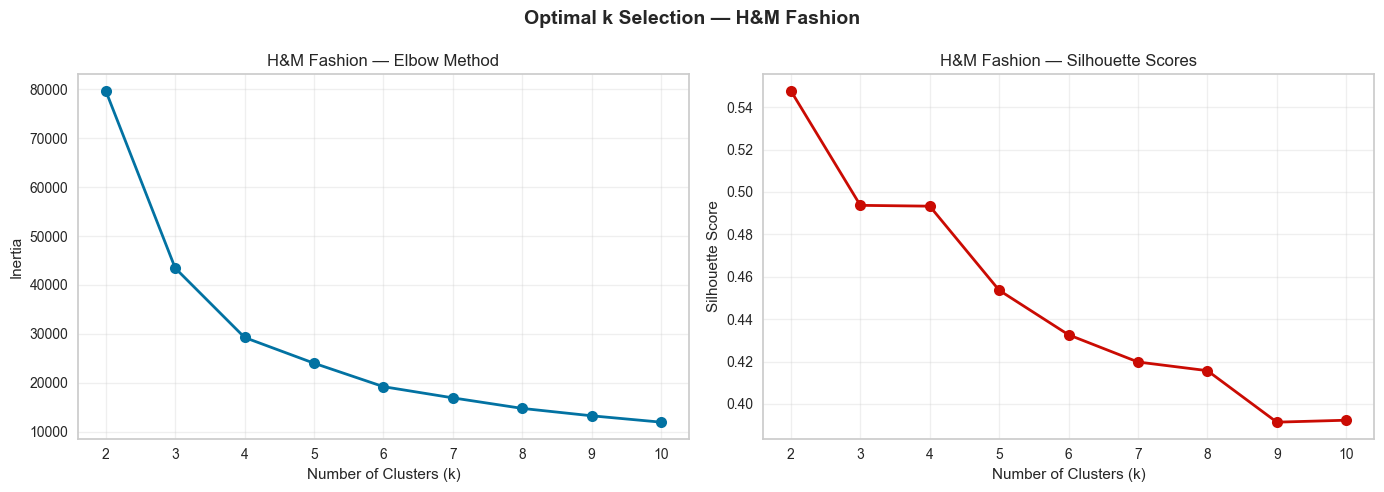

Chart saved → C:\Users\aniru\OneDrive\Desktop\Retail Seg\outputs\elbow_h&m_fashion.png

   k |      Inertia | Silhouette
--------------------------------
   2 |     79,616.8 |     0.5477
   3 |     43,446.4 |     0.4937
   4 |     29,287.4 |     0.4933
   5 |     24,033.6 |     0.4536
   6 |     19,248.2 |     0.4326
   7 |     16,963.0 |     0.4198
   8 |     14,811.2 |     0.4157
   9 |     13,302.8 |     0.3914
  10 |     12,004.6 |     0.3923

→ Best k by silhouette: 2


In [17]:
# H&M
hm_sample_idx = np.random.RandomState(42).choice(len(rfm_hm_capped), size=50000, replace=False)
scaled_hm_full, scaler_hm = scale_rfm(rfm_hm_capped)
scaled_hm_sample = scaled_hm_full[hm_sample_idx]
best_k_hm = find_optimal_k(scaled_hm_sample, 'H&M Fashion')

In [18]:
# H&M fit
rfm_hm_c, km_hm = run_kmeans(rfm_hm_capped, scaled_hm_full, 4, 'H&M Fashion')


H&M Fashion — K-Means with k=4
cluster
0     64204
1    664768
2    400404
3    232905
Name: count, dtype: int64


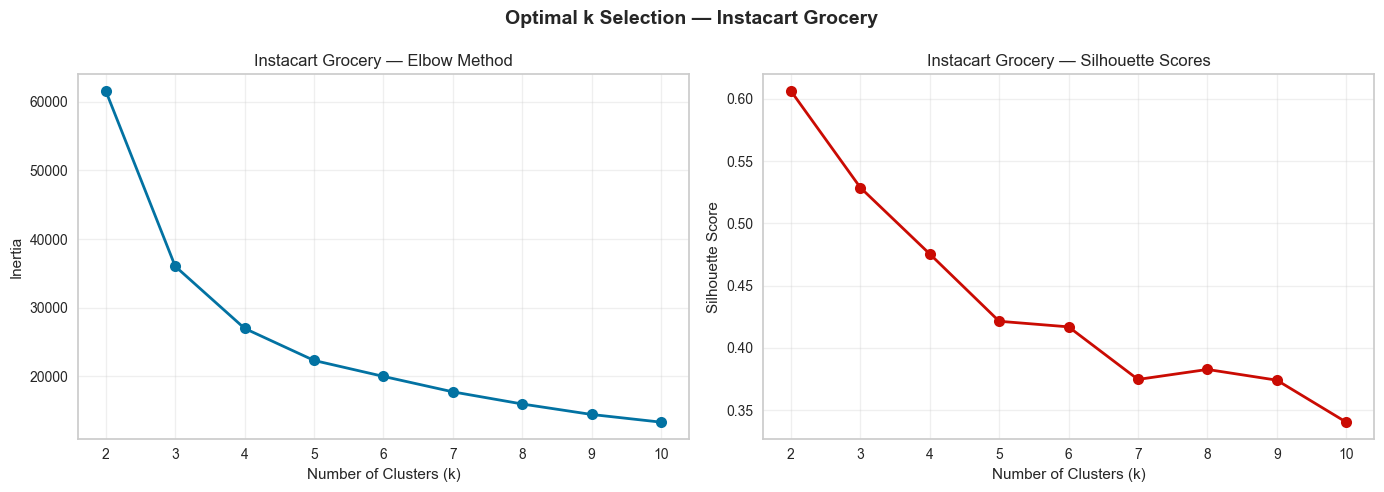

Chart saved → C:\Users\aniru\OneDrive\Desktop\Retail Seg\outputs\elbow_instacart_grocery.png

   k |      Inertia | Silhouette
--------------------------------
   2 |     61,586.8 |     0.6062
   3 |     36,027.0 |     0.5287
   4 |     26,970.3 |     0.4754
   5 |     22,300.2 |     0.4213
   6 |     19,972.6 |     0.4168
   7 |     17,720.8 |     0.3746
   8 |     15,948.3 |     0.3826
   9 |     14,421.3 |     0.3740
  10 |     13,302.3 |     0.3403

→ Best k by silhouette: 2


In [19]:
# Instacart
inst_sample_idx = np.random.RandomState(42).choice(len(rfm_inst_capped), size=50000, replace=False)
scaled_inst_full, scaler_inst = scale_rfm(rfm_inst_capped)
scaled_inst_sample = scaled_inst_full[inst_sample_idx]
best_k_inst = find_optimal_k(scaled_inst_sample, 'Instacart Grocery')

In [20]:
# Instacart fit
rfm_inst_c, km_inst = run_kmeans(rfm_inst_capped, scaled_inst_full, 4, 'Instacart Grocery')


Instacart Grocery — K-Means with k=4
cluster
0    104561
1     11762
2     30716
3     59170
Name: count, dtype: int64


In [14]:
# Look at the tiny clusters
print("UCI — Tiny cluster profiles:")
print(rfm_uci_c[rfm_uci_c['cluster'].isin([2, 3])][
    ['customer_id','recency','frequency','monetary','segment','cluster']
].sort_values('monetary', ascending=False).to_string())

print("\nUCI — Overall monetary stats:")
print(rfm_uci_c['monetary'].describe().round(2))

print("\nUCI — Monetary stats by cluster:")
print(rfm_uci_c.groupby('cluster')['monetary'].describe().round(2).to_string())

UCI — Tiny cluster profiles:
     customer_id  recency  frequency    monetary             segment  cluster
5692       18102        1        145  580987.040           Champions        2
2277       14646        2        151  528602.520           Champions        2
1789       14156       10        156  313437.620           Champions        2
2538       14911        1        398  291420.810           Champions        2
5050       17450        8         51  244784.250           Champions        3
1331       13694        4        143  195640.690           Champions        3
5109       17511        3         60  172132.870           Champions        3
4061       16446        1          2  168472.500       New Customers        3
4295       16684        4         55  147142.770           Champions        3
68         12415       24         28  144458.370           Champions        3
2685       15061        4        127  126389.020           Champions        3
3647       16029       39        10

In [21]:
def profile_clusters(rfm_c, name):
    """Print and return a cluster profile summary."""
    profile = rfm_c.groupby('cluster').agg(
        n_customers  = ('customer_id',  'count'),
        avg_recency  = ('recency',      'mean'),
        avg_frequency= ('frequency',    'mean'),
        avg_monetary = ('monetary',     'mean'),
        avg_rfm_score= ('rfm_score',    'mean'),
        top_segment  = ('segment', lambda x: x.value_counts().index[0])
    ).round(1)

    profile['pct_customers'] = (
        profile['n_customers'] / profile['n_customers'].sum() * 100
    ).round(1)

    print(f"\n{'='*60}")
    print(f"Cluster Profiles — {name}")
    print(f"{'='*60}")
    print(profile.to_string())
    return profile


profile_uci  = profile_clusters(rfm_uci_c,  'UCI Online Retail')
profile_hm   = profile_clusters(rfm_hm_c,   'H&M Fashion')
profile_inst = profile_clusters(rfm_inst_c, 'Instacart Grocery')


Cluster Profiles — UCI Online Retail
         n_customers  avg_recency  avg_frequency  avg_monetary  avg_rfm_score      top_segment  pct_customers
cluster                                                                                                      
0               3008         84.0            3.8        1191.5            9.5  Loyal Customers           51.2
1               1867        475.4            2.0         652.6            5.5       Occasional           31.8
2                196         37.6           34.4       20500.1           14.5        Champions            3.3
3                807         44.5           14.9        5854.1           14.0        Champions           13.7

Cluster Profiles — H&M Fashion
         n_customers  avg_recency  avg_frequency  avg_monetary  avg_rfm_score      top_segment  pct_customers
cluster                                                                                                      
0              64204         33.8           32.8  

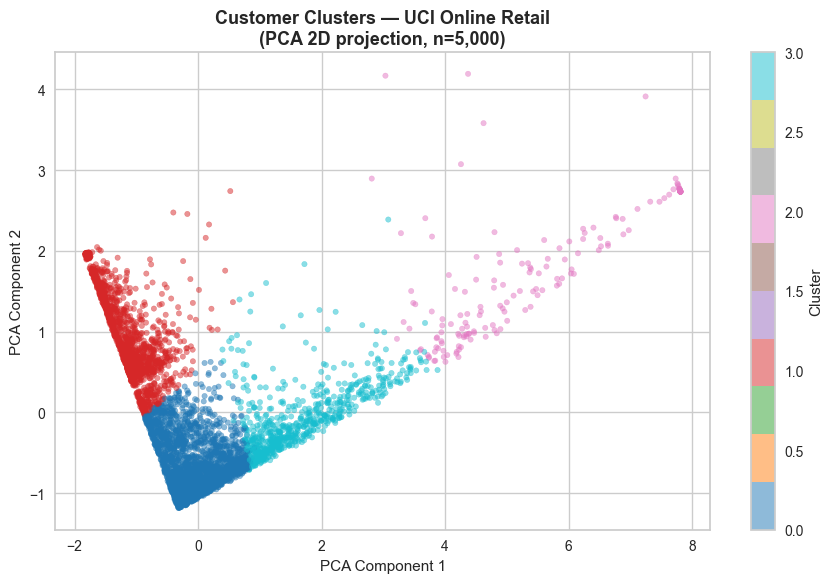

Chart saved → C:\Users\aniru\OneDrive\Desktop\Retail Seg\outputs\clusters_uci_online_retail.png


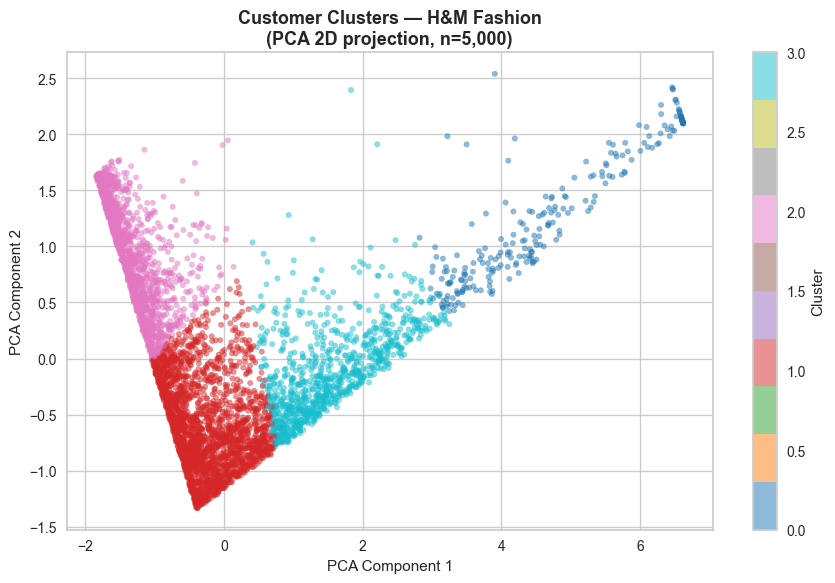

Chart saved → C:\Users\aniru\OneDrive\Desktop\Retail Seg\outputs\clusters_h&m_fashion.png


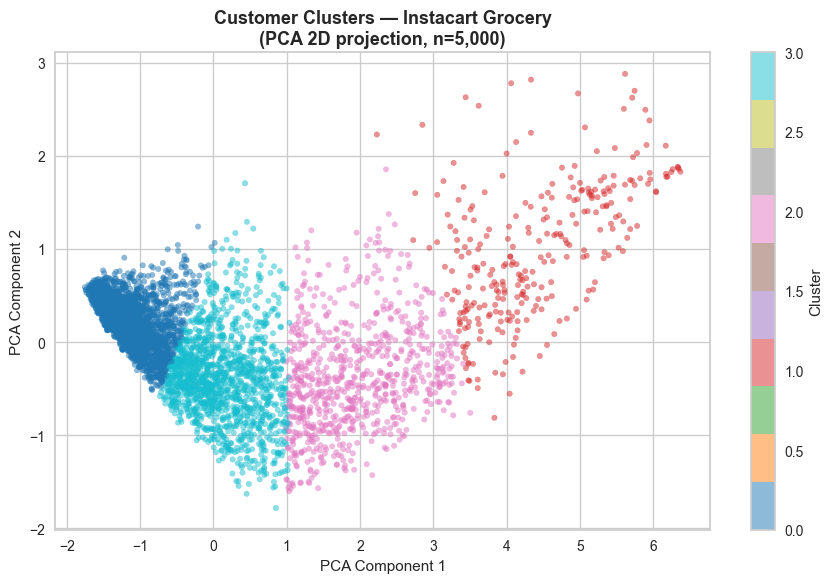

Chart saved → C:\Users\aniru\OneDrive\Desktop\Retail Seg\outputs\clusters_instacart_grocery.png


In [25]:
from sklearn.decomposition import PCA

def plot_clusters(rfm_c, scaled_data, name, sample_n=5000):
    """PCA scatter plot of clusters — sampled for speed."""
    idx = np.random.RandomState(42).choice(len(rfm_c), size=min(sample_n, len(rfm_c)), replace=False)
    sample_scaled  = scaled_data[idx]
    sample_labels  = rfm_c['cluster'].values[idx]

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(sample_scaled)

    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(
        coords[:, 0], coords[:, 1],
        c=sample_labels, cmap='tab10',
        alpha=0.5, s=15
    )
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Customer Clusters — {name}\n(PCA 2D projection, n={len(idx):,})',
              fontsize=13, fontweight='bold')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.tight_layout()

    fname = os.path.join(OUTPUTS, f'clusters_{name.lower().replace(" ","_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved → {fname}")

plot_clusters(rfm_uci_c,  scaled_uci,      'UCI Online Retail')
plot_clusters(rfm_hm_c,   scaled_hm_full,  'H&M Fashion')
plot_clusters(rfm_inst_c, scaled_inst_full,     'Instacart Grocery')

In [23]:
# ── UCI cluster labels ─────────────────────────────────
uci_label_map = {
    2: 'VIP Wholesale',
    3: 'Champions',
    0: 'Loyal Regulars',
    1: 'Lapsed'
}

# ── H&M cluster labels ────────────────────────────────
hm_label_map = {
    0: 'VIP Fashion',
    3: 'Champions',
    1: 'Casual Shoppers',
    2: 'Lapsed'
}

# ── Instacart cluster labels ──────────────────────────
inst_label_map = {
    1: 'Power Shoppers',
    2: 'Loyal Regulars',
    3: 'Occasional Buyers',
    0: 'Lapsed'
}

rfm_uci_c['cluster_label']  = rfm_uci_c['cluster'].map(uci_label_map)
rfm_hm_c['cluster_label']   = rfm_hm_c['cluster'].map(hm_label_map)
rfm_inst_c['cluster_label'] = rfm_inst_c['cluster'].map(inst_label_map)

# Verify
for name, df in [('UCI', rfm_uci_c), ('H&M', rfm_hm_c), ('Instacart', rfm_inst_c)]:
    print(f"\n{name}:")
    print(df['cluster_label'].value_counts().to_string())


UCI:
cluster_label
Loyal Regulars    3008
Lapsed            1867
Champions          807
VIP Wholesale      196

H&M:
cluster_label
Casual Shoppers    664768
Lapsed             400404
Champions          232905
VIP Fashion         64204

Instacart:
cluster_label
Lapsed               104561
Occasional Buyers     59170
Loyal Regulars        30716
Power Shoppers        11762


In [24]:
rfm_uci_c.to_parquet(os.path.join(PROCESSED,  'rfm_uci_clustered.parquet'),  index=False)
rfm_hm_c.to_parquet(os.path.join(PROCESSED,   'rfm_hm_clustered.parquet'),   index=False)
rfm_inst_c.to_parquet(os.path.join(PROCESSED, 'rfm_inst_clustered.parquet'), index=False)

print("Clustered RFM tables saved ✓")
for name, df in [('UCI', rfm_uci_c), ('H&M', rfm_hm_c), ('Instacart', rfm_inst_c)]:
    print(f"  {name:12} — {len(df):>10,} customers | {df['cluster'].nunique()} clusters")

Clustered RFM tables saved ✓
  UCI          —      5,878 customers | 4 clusters
  H&M          —  1,362,281 customers | 4 clusters
  Instacart    —    206,209 customers | 4 clusters
